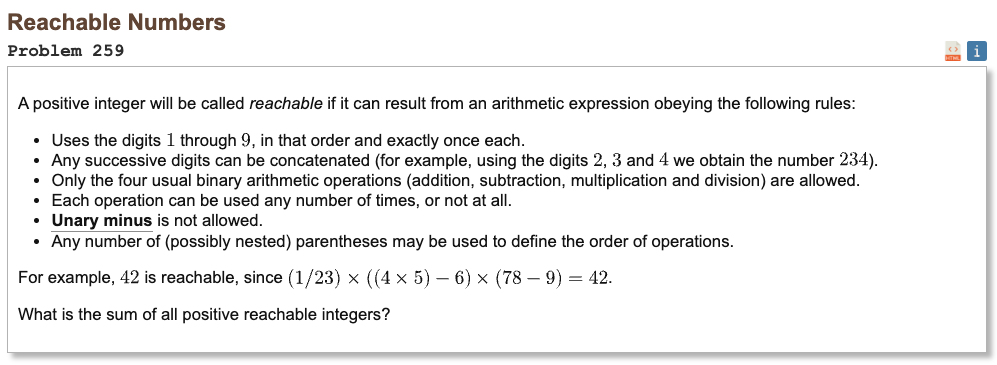

## Initial approach

* we must use digits 1 to 9 in order and exactly once
* digits can be concatenated into bigger numbers before operations
* only +, -, *, / are allowed and no unary minus
* build all possible values by splitting the digit string into two parts recursively
* for each split, combine left and right results using the four operations
* store values as exact rational numbers to avoid floating point errors
* collect all positive integers that appear
* sum them and print the result

In [1]:
from fractions import Fraction

digits = "123456789"
memo = {}

def compute(s):
    if s in memo:
        return memo[s]

    results = set()
    results.add(Fraction(int(s), 1))

    for i in range(1, len(s)):
        left = s[:i]
        right = s[i:]

        left_vals = compute(left)
        right_vals = compute(right)

        for a in left_vals:
            for b in right_vals:
                results.add(a + b)
                results.add(a - b)
                results.add(a * b)
                if b != 0:
                    results.add(a / b)

    memo[s] = results
    return results

def solve():
    values = compute(digits)
    total = 0
    for v in values:
        if v.denominator == 1 and v.numerator > 0:
            total += v.numerator
    print("Result:", total)

In [2]:
%%time
solve()

Result: 20101196798
CPU times: user 27.9 s, sys: 217 ms, total: 28.2 s
Wall time: 28.4 s
